# Entrenamiento y Evaluación de Modelos - EnergiAI

Entrenar, evaluar y serializar el modelo de clasificación energética

### 1. Configuración inicial y carga de datos

In [38]:
# Importar librerías y configurar entorno
import os
import sys
import warnings
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Configuración
warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_palette("Set2")
%matplotlib inline

In [3]:
# Definir rutas
DATA_PATH = '../data/processed/dataset_extendido.csv'
MODELS_PATH = '../models/saved/'
#OUTPUT_IMAGES_PATH = '../images/modelos/'

# Crear carpeta de modelos si no existe
os.makedirs(MODELS_PATH, exist_ok=True)
#os.makedirs(OUTPUT_IMAGES_PATH, exist_ok=True)

# Cargar datos
df = pd.read_csv(DATA_PATH)

print("Dataset extendido cargado correctamente.")
print(f"Dimensiones: {df.shape[0]} filas, {df.shape[1]} columnas.")
print("\nPrimeras 5 filas:")
display(df.head())

# Verificación rápida
print("\nInformación general:")
df.info()
print("\nValores nulos por columna:")
print(df.isnull().sum())

Dataset extendido cargado correctamente.
Dimensiones: 3000 filas, 10 columnas.

Primeras 5 filas:


,consumo_kwh,cantidad_equipos,horas_alto_consumo,tipo_inmueble,uso_horario_pico,numero_habitantes,antiguedad_inmueble,calefaccion,aire_acondicionado,categoria
0,1128,13,2,Casa,True,6,44,True,False,Moderado
1,1500,12,9,Local,True,4,46,False,True,Ineficiente
2,1348,6,6,Oficina,True,1,26,True,False,Moderado
3,241,19,10,Apartamento,False,3,11,True,False,Moderado
4,546,20,3,Apartamento,False,3,12,False,False,Eficiente



Información general:
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   consumo_kwh          3000 non-null   int64
 1   cantidad_equipos     3000 non-null   int64
 2   horas_alto_consumo   3000 non-null   int64
 3   tipo_inmueble        3000 non-null   str  
 4   uso_horario_pico     3000 non-null   bool 
 5   numero_habitantes    3000 non-null   int64
 6   antiguedad_inmueble  3000 non-null   int64
 7   calefaccion          3000 non-null   bool 
 8   aire_acondicionado   3000 non-null   bool 
 9   categoria            3000 non-null   str  
dtypes: bool(3), int64(5), str(2)
memory usage: 173.0 KB

Valores nulos por columna:
consumo_kwh            0
cantidad_equipos       0
horas_alto_consumo     0
tipo_inmueble          0
uso_horario_pico       0
numero_habitantes      0
antiguedad_inmueble    0
calefaccion            0
aire_acondicionado   

### 2. Análisis exploratorio rápido

Distribución de la variable objetivo:
categoria
Moderado       2202
Ineficiente     638
Eficiente       160
Name: count, dtype: int64

Proporciones:
categoria
Moderado       0.734
Ineficiente    0.213
Eficiente      0.053
Name: proportion, dtype: float64


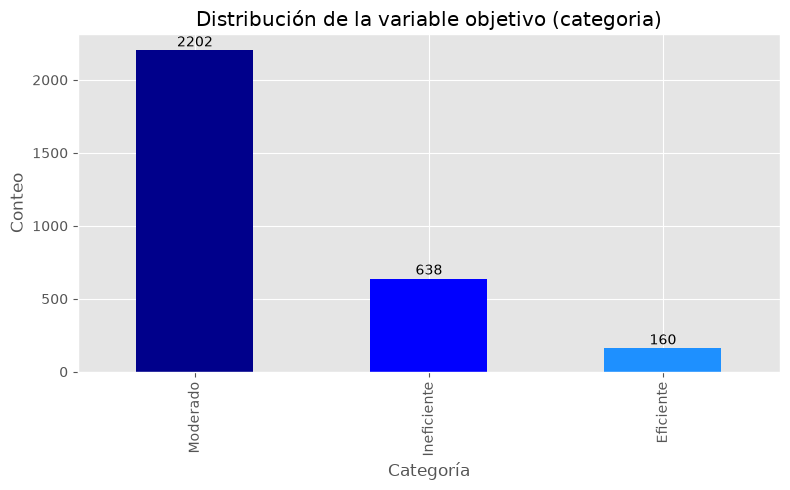

In [ ]:
# Distribución de la variable objetivo
print("Distribución de la variable objetivo:")
print(df['categoria'].value_counts())
print(f"\nProporciones:\n{df['categoria'].value_counts(normalize=True).round(3)}")
# 'darkblue', 'blue', 'dodgerblue', 'deepskyblue'
# Gráfico de barras
fig, ax = plt.subplots(figsize=(8, 5))
df['categoria'].value_counts().plot(kind='bar', ax=ax, color=['darkblue', 'blue', 'dodgerblue'])
ax.set_title('Distribución de la variable objetivo (categoria)')
ax.set_xlabel('Categoría')
ax.set_ylabel('Conteo')

for i, v in enumerate(df['categoria'].value_counts()):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')

plt.tight_layout()
# plt.savefig(f'{OUTPUT_IMAGES_PATH}/distribucion_categoria_extendido.png', dpi=150, bbox_inches='tight')
plt.show()

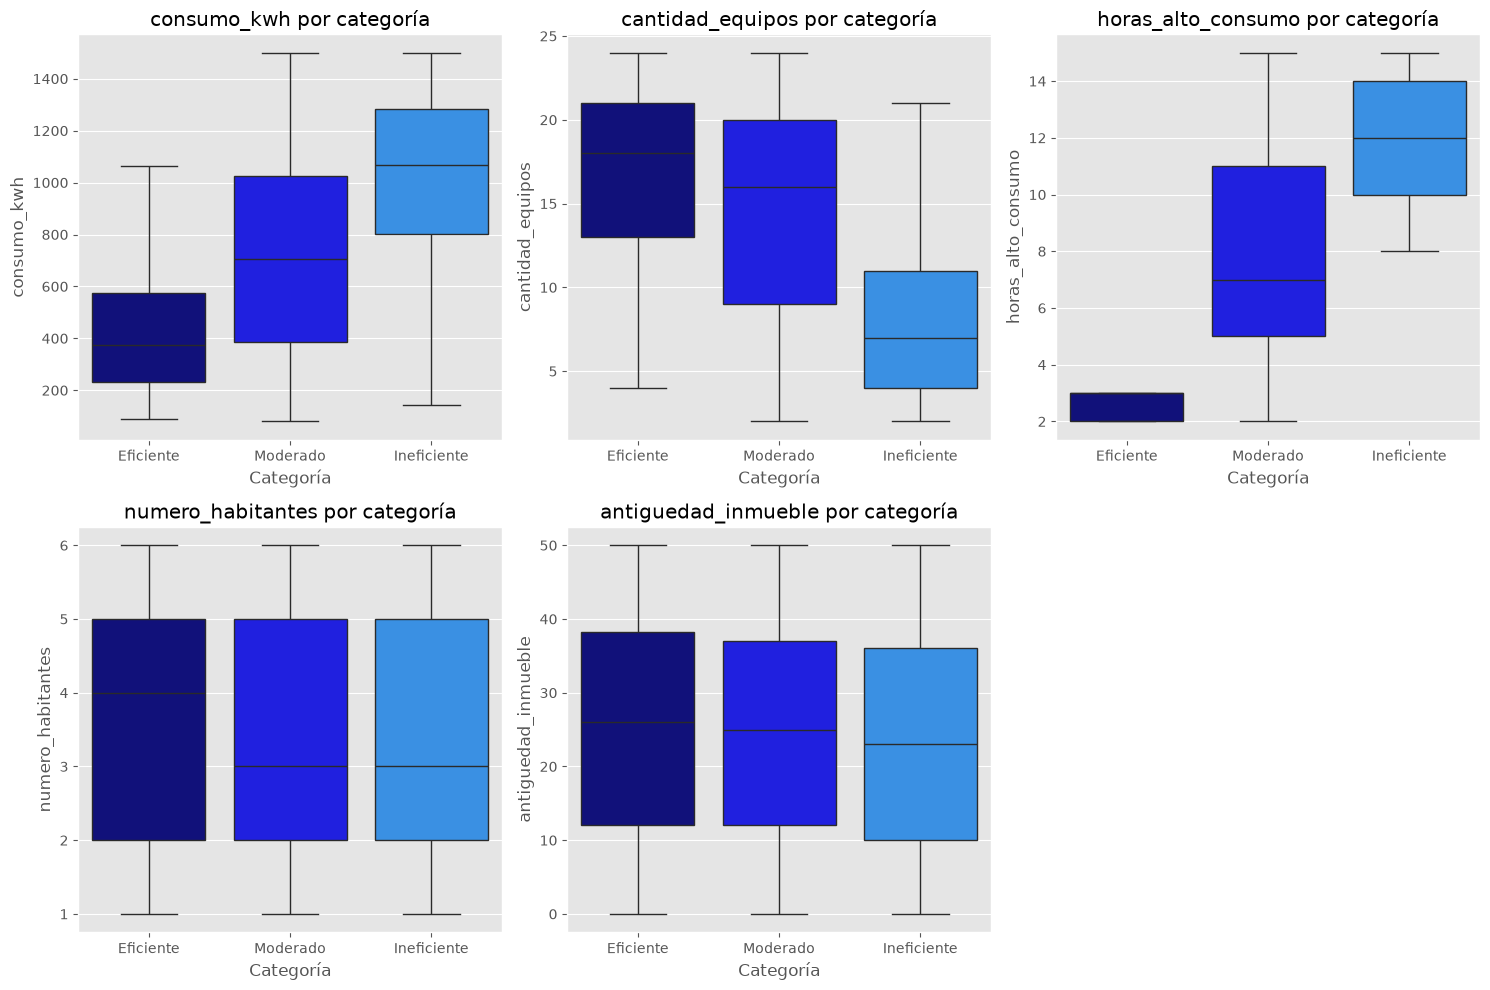

In [18]:
# Boxplots de variables numéricas por categoría
num_cols = ['consumo_kwh', 'cantidad_equipos', 'horas_alto_consumo', 
            'numero_habitantes', 'antiguedad_inmueble']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='categoria', y=col, ax=axes[i], 
                order=['Eficiente', 'Moderado', 'Ineficiente'], palette=['darkblue', 'blue', 'dodgerblue'])
    axes[i].set_title(f'{col} por categoría')
    axes[i].set_xlabel('Categoría')
    axes[i].set_ylabel(col)

# Ocultar el subplot sobrante
if len(num_cols) < len(axes):
    for j in range(len(num_cols), len(axes)):
        axes[j].axis('off')

plt.tight_layout()
# plt.savefig(f'{OUTPUT_IMAGES_PATH}/boxplots_num_por_categoria.png', dpi=150, bbox_inches='tight')
plt.show()

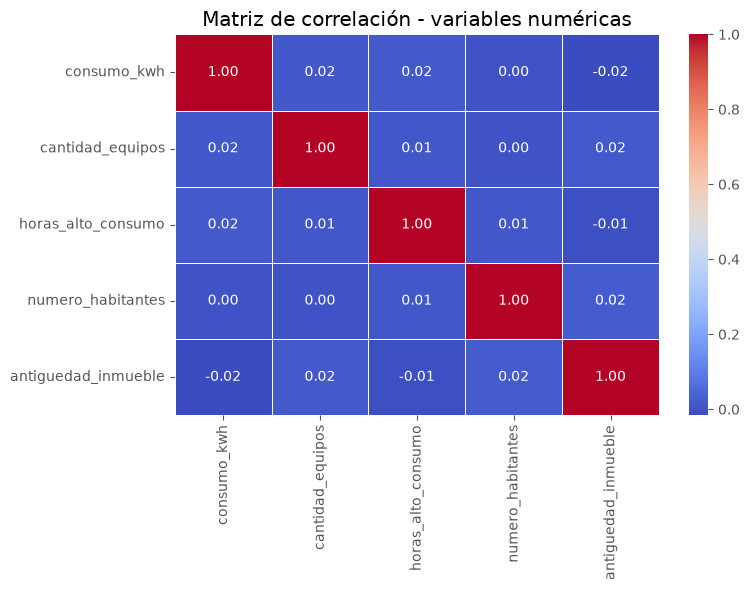

In [22]:
# Matriz de correlación entre variables numéricas
corr_cols = ['consumo_kwh', 'cantidad_equipos', 'horas_alto_consumo', 
             'numero_habitantes', 'antiguedad_inmueble']

plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de correlación - variables numéricas')
plt.tight_layout()
# plt.savefig(f'{OUTPUT_IMAGES_PATH}/matriz_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# Variables categóricas y valores únicos
cat_cols = ['tipo_inmueble', 'uso_horario_pico', 'calefaccion', 'aire_acondicionado']

print("Variables categóricas y sus valores únicos:")
for col in cat_cols:
    print(f"\n (variable) {col}:")
    print(f"   Valores únicos: {df[col].unique()}")
    print(f"   Frecuencias:\n{df[col].value_counts()}")

Variables categóricas y sus valores únicos:

 (variable) tipo_inmueble:
   Valores únicos: <StringArray>
['Casa', 'Local', 'Oficina', 'Apartamento']
Length: 4, dtype: str
   Frecuencias:
tipo_inmueble
Casa           1179
Apartamento     903
Local           498
Oficina         420
Name: count, dtype: int64

 (variable) uso_horario_pico:
   Valores únicos: [ True False]
   Frecuencias:
uso_horario_pico
False    1656
True     1344
Name: count, dtype: int64

 (variable) calefaccion:
   Valores únicos: [ True False]
   Frecuencias:
calefaccion
False    1925
True     1075
Name: count, dtype: int64

 (variable) aire_acondicionado:
   Valores únicos: [False  True]
   Frecuencias:
aire_acondicionado
False    1768
True     1232
Name: count, dtype: int64


### 3. Preprocesamiento de datos

In [29]:
# Separar características (X) y variable objetivo (y)

X = df.drop(columns=['categoria'])
y = df['categoria']

print("Características (X):")
print(f"Dimensiones: {X.shape}")
print(f"Columnas: {X.columns.tolist()}")

print("\nVariable objetivo (y):")
print(f"Dimensiones: {y.shape}")
print(f"Distribución:\n{y.value_counts()}")

Características (X):
Dimensiones: (3000, 9)
Columnas: ['consumo_kwh', 'cantidad_equipos', 'horas_alto_consumo', 'tipo_inmueble', 'uso_horario_pico', 'numero_habitantes', 'antiguedad_inmueble', 'calefaccion', 'aire_acondicionado']

Variable objetivo (y):
Dimensiones: (3000,)
Distribución:
categoria
Moderado       2202
Ineficiente     638
Eficiente       160
Name: count, dtype: int64


In [33]:
# Codificación de variables categóricas

X_encoded = X.copy()

# OneHotEncoder para tipo_inmueble
X_encoded = pd.get_dummies(X_encoded, columns=['tipo_inmueble'], drop_first=True)

# LabelEncoder para binarias (convertir bool a int)
X_encoded['uso_horario_pico'] = X_encoded['uso_horario_pico'].astype(int)
X_encoded['calefaccion'] = X_encoded['calefaccion'].astype(int)
X_encoded['aire_acondicionado'] = X_encoded['aire_acondicionado'].astype(int)

print("Variables codificadas:")
print(X_encoded.head())

Variables codificadas:
   consumo_kwh  cantidad_equipos  horas_alto_consumo  uso_horario_pico  \
0         1128                13                   2                 1   
1         1500                12                   9                 1   
2         1348                 6                   6                 1   
3          241                19                  10                 0   
4          546                20                   3                 0   

   numero_habitantes  antiguedad_inmueble  calefaccion  aire_acondicionado  \
0                  6                   44            1                   0   
1                  4                   46            0                   1   
2                  1                   26            1                   0   
3                  3                   11            1                   0   
4                  3                   12            0                   0   

   tipo_inmueble_Casa  tipo_inmueble_Local  tipo_inmueble_Ofici

In [34]:
# Escalado de variables numéricas

# Seleccionar columnas numéricas originales (sin codificar)
num_cols_original = ['consumo_kwh', 'cantidad_equipos', 'horas_alto_consumo', 
                     'numero_habitantes', 'antiguedad_inmueble']

# Crear y ajustar el escalador
scaler = StandardScaler()
X_scaled = X_encoded.copy()
X_scaled[num_cols_original] = scaler.fit_transform(X_encoded[num_cols_original])

print("Variables numéricas escaladas:")
print(f"Media de consumo_kwh después de escalar: {X_scaled['consumo_kwh'].mean():.2f}")
print(f"Desviación estándar de consumo_kwh: {X_scaled['consumo_kwh'].std():.2f}")
print("\nPrimeras 5 filas del dataset preprocesado:")
print(X_scaled.head())

Variables numéricas escaladas:
Media de consumo_kwh después de escalar: -0.00
Desviación estándar de consumo_kwh: 1.00

Primeras 5 filas del dataset preprocesado:
   consumo_kwh  cantidad_equipos  horas_alto_consumo  uso_horario_pico  \
0     0.893130         -0.065139           -1.609180                 1   
1     1.827026         -0.215115            0.137397                 1   
2     1.445434         -1.114967           -0.611136                 1   
3    -1.333660          0.834713            0.386909                 0   
4    -0.567965          0.984689           -1.359669                 0   

   numero_habitantes  antiguedad_inmueble  calefaccion  aire_acondicionado  \
0           1.470134             1.309879            1                   0   
1           0.305825             1.445206            0                   1   
2          -1.440638             0.091932            1                   0   
3          -0.276329            -0.923023            1                   0   
4 

In [35]:
# Dividir manteniendo la proporción de clases (estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("División de datos completada:")
print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba: {X_test.shape[0]} muestras")
print(f"\nDistribución en entrenamiento:\n{y_train.value_counts()}")
print(f"\nDistribución en prueba:\n{y_test.value_counts()}")

División de datos completada:
Entrenamiento: 2400 muestras
Prueba: 600 muestras

Distribución en entrenamiento:
categoria
Moderado       1762
Ineficiente     510
Eficiente       128
Name: count, dtype: int64

Distribución en prueba:
categoria
Moderado       440
Ineficiente    128
Eficiente       32
Name: count, dtype: int64


In [36]:
# Guardar el escalador y el preprocesador (si usaste ColumnTransformer)
joblib.dump(scaler, f'{MODELS_PATH}/scaler.pkl')

# Si usaste ColumnTransformer, guárdalo también:
# joblib.dump(preprocessor, f'{MODELS_PATH}/preprocessor.pkl')

print("Preprocesadores guardados en:", MODELS_PATH)

Preprocesadores guardados en: ../models/saved/


### 4. Entrenamiento de modelos base

In [39]:
# Instanciar modelos
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Diccionario para guardar los modelos entrenados
trained_models = {}

print("Entrenando modelos base...")
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()
    trained_models[name] = model
    print(f"{name} entrenado en {end - start:.2f} segundos")

Entrenando modelos base...
Logistic Regression entrenado en 0.07 segundos
Decision Tree entrenado en 0.02 segundos
Random Forest entrenado en 0.41 segundos



 (MODELO) Logistic Regression
   Accuracy: 0.9100
   F1-score (weighted): 0.9065

   Classification Report:
              precision    recall  f1-score   support

   Eficiente       0.90      0.59      0.72        32
 Ineficiente       0.90      0.78      0.84       128
    Moderado       0.91      0.97      0.94       440

    accuracy                           0.91       600
   macro avg       0.91      0.78      0.83       600
weighted avg       0.91      0.91      0.91       600



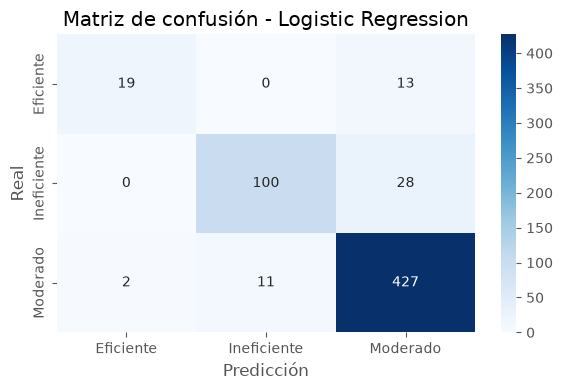


 (MODELO) Decision Tree
   Accuracy: 0.9667
   F1-score (weighted): 0.9667

   Classification Report:
              precision    recall  f1-score   support

   Eficiente       0.91      0.91      0.91        32
 Ineficiente       0.95      0.95      0.95       128
    Moderado       0.98      0.98      0.98       440

    accuracy                           0.97       600
   macro avg       0.94      0.94      0.94       600
weighted avg       0.97      0.97      0.97       600



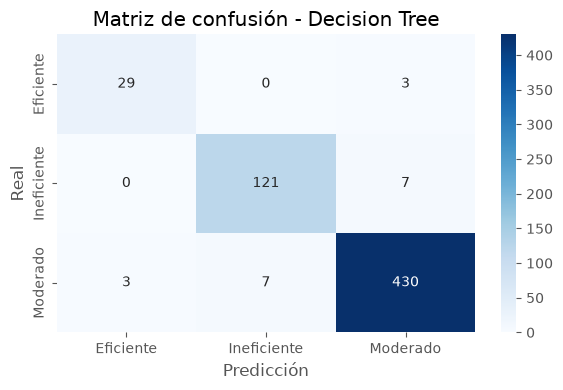


 (MODELO) Random Forest
   Accuracy: 0.9717
   F1-score (weighted): 0.9710

   Classification Report:
              precision    recall  f1-score   support

   Eficiente       1.00      0.81      0.90        32
 Ineficiente       1.00      0.91      0.96       128
    Moderado       0.96      1.00      0.98       440

    accuracy                           0.97       600
   macro avg       0.99      0.91      0.94       600
weighted avg       0.97      0.97      0.97       600



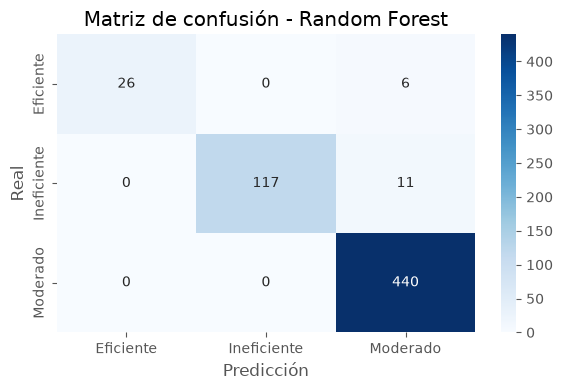

In [42]:
# Evaluación de modelos

# Diccionario para almacenar resultados
results = {}

for name, model in trained_models.items():
    # Predicciones
    y_pred = model.predict(X_test)
    
    # Métricas
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Guardar resultados
    results[name] = {
        'accuracy': acc,
        'f1_weighted': f1,
        'y_pred': y_pred
    }
    
    print(f"\n (MODELO) {name}")
    print(f"   Accuracy: {acc:.4f}")
    print(f"   F1-score (weighted): {f1:.4f}")
    print("\n   Classification Report:")
    print(classification_report(y_test, y_pred))
    
    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title(f'Matriz de confusión - {name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.tight_layout()
    # plt.savefig(f'{OUTPUT_IMAGES_PATH}/confusion_{name.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

Comparación de modelos base:
             Modelo  Accuracy  F1-score (weighted)
Logistic Regression  0.910000             0.906482
      Decision Tree  0.966667             0.966667
      Random Forest  0.971667             0.971006


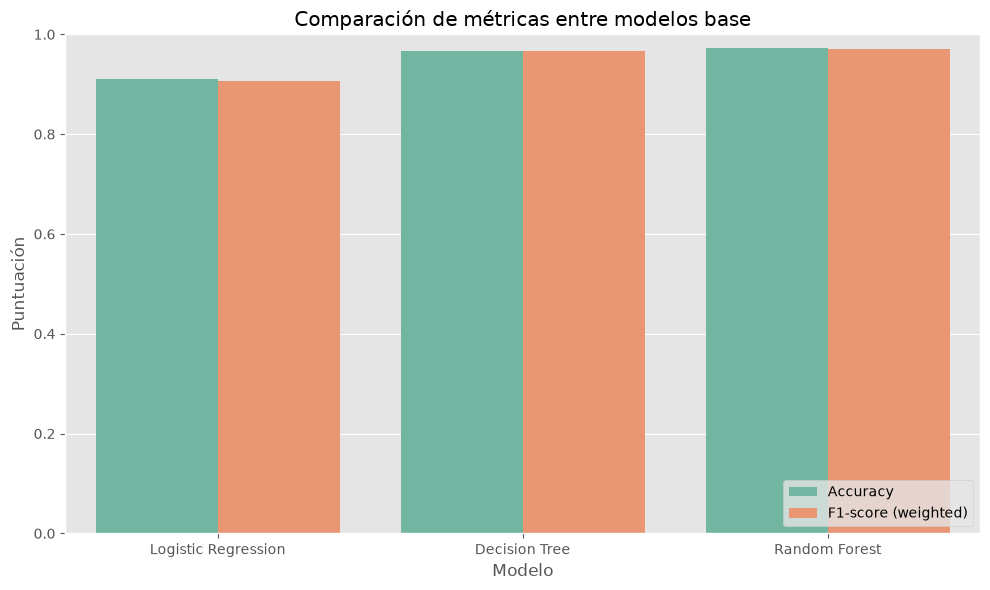


 >>> Mejor modelo base: Random Forest con F1-score = 0.9710


In [43]:
# Crear DataFrame con resultados
comparison_df = pd.DataFrame({
    'Modelo': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results],
    'F1-score (weighted)': [results[m]['f1_weighted'] for m in results]
})

print("Comparación de modelos base:")
print(comparison_df.to_string(index=False))

# Gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(10, 6))
comparison_df_melted = comparison_df.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')
sns.barplot(data=comparison_df_melted, x='Modelo', y='Valor', hue='Métrica', palette='Set2')
ax.set_title('Comparación de métricas entre modelos base')
ax.set_ylim(0, 1)
ax.set_ylabel('Puntuación')
ax.set_xlabel('Modelo')
plt.legend(loc='lower right')
plt.tight_layout()
# plt.savefig(f'{OUTPUT_IMAGES_PATH}/comparacion_modelos_base.png', dpi=150, bbox_inches='tight')
plt.show()

# Identificar el mejor modelo
best_model_name = comparison_df.loc[comparison_df['F1-score (weighted)'].idxmax(), 'Modelo']
best_f1 = comparison_df['F1-score (weighted)'].max()
print(f"\n >>> Mejor modelo base: {best_model_name} con F1-score = {best_f1:.4f}")

### 5. Serialización del modelo final

In [44]:
# Guardar el mejor modelo
best_model = trained_models['Random Forest']
joblib.dump(best_model, f'{MODELS_PATH}/modelo_energia.pkl')

# Guardar el escalador
joblib.dump(scaler, f'{MODELS_PATH}/scaler.pkl')

# Guardar los nombres de las columnas (para la API)
feature_names = X_scaled.columns.tolist()
joblib.dump(feature_names, f'{MODELS_PATH}/feature_names.pkl')

# Guardar las clases (categorías) para la predicción
classes = best_model.classes_
joblib.dump(classes, f'{MODELS_PATH}/classes.pkl')

print("Modelo y preprocesadores guardados correctamente en:", MODELS_PATH)
print(f"   - modelo_energia.pkl: {best_model.__class__.__name__}")
print(f"   - scaler.pkl: {scaler.__class__.__name__}")
print(f"   - feature_names.pkl: {len(feature_names)} características")
print(f"   - classes.pkl: {classes}")

Modelo y preprocesadores guardados correctamente en: ../models/saved/
   - modelo_energia.pkl: RandomForestClassifier
   - scaler.pkl: StandardScaler
   - feature_names.pkl: 11 características
   - classes.pkl: ['Eficiente' 'Ineficiente' 'Moderado']


In [53]:
#  Prueba de inferencia

import json

# Cargar modelo y preprocesadores
loaded_model = joblib.load(f'{MODELS_PATH}/modelo_energia.pkl')
loaded_scaler = joblib.load(f'{MODELS_PATH}/scaler.pkl')
loaded_feature_names = joblib.load(f'{MODELS_PATH}/feature_names.pkl')
loaded_classes = joblib.load(f'{MODELS_PATH}/classes.pkl')

print("Modelo y preprocesadores cargados correctamente.")

# Crear un ejemplo de entrada (simulando un usuario)
ejemplo = pd.DataFrame([{
    'consumo_kwh': 600,
    'cantidad_equipos': 15,
    'horas_alto_consumo': 8,
    'tipo_inmueble': 'Casa',
    'uso_horario_pico': True,
    'numero_habitantes': 4,
    'antiguedad_inmueble': 20,
    'calefaccion': False,
    'aire_acondicionado': True
}])

print("\nDatos de ejemplo (entrada del usuario):")
print(ejemplo)

# Aplicar el mismo preprocesamiento que usamos en el entrenamiento
# 1. Codificar variables categóricas
ejemplo_encoded = ejemplo.copy()
ejemplo_encoded = pd.get_dummies(ejemplo_encoded, columns=['tipo_inmueble'], drop_first=True)
ejemplo_encoded['uso_horario_pico'] = ejemplo_encoded['uso_horario_pico'].astype(int)
ejemplo_encoded['calefaccion'] = ejemplo_encoded['calefaccion'].astype(int)
ejemplo_encoded['aire_acondicionado'] = ejemplo_encoded['aire_acondicionado'].astype(int)

# Asegurar que tenga las mismas columnas que el entrenamiento
for col in loaded_feature_names:
    if col not in ejemplo_encoded.columns:
        ejemplo_encoded[col] = 0

# Reordenar columnas
ejemplo_encoded = ejemplo_encoded[loaded_feature_names]

# 2. Escalar variables numéricas
num_cols_original = ['consumo_kwh', 'cantidad_equipos', 'horas_alto_consumo', 
                     'numero_habitantes', 'antiguedad_inmueble']
ejemplo_encoded[num_cols_original] = loaded_scaler.transform(ejemplo_encoded[num_cols_original])

print("\nDatos preprocesados (entrada al modelo):")
print(ejemplo_encoded)

# 3. Realizar predicción
prediccion = loaded_model.predict(ejemplo_encoded)
probabilidad = loaded_model.predict_proba(ejemplo_encoded)

print("\nResultado de la predicción:")
print(f"Categoría predicha: {prediccion[0]}")
print("Probabilidades por clase:")
for i, cls in enumerate(loaded_classes):
    print(f"   {cls}: {probabilidad[0][i]:.4f}")

# 4. Construir salida JSON (como la espera el backend)
salida_json = {
    "categoria": prediccion[0],
    "probabilidad": float(max(probabilidad[0])),
    "distancias": {
        cls: float(probabilidad[0][i]) for i, cls in enumerate(loaded_classes)
    }
}

print("\n\nSalida JSON simulada para la API:")
print(json.dumps(salida_json, indent=2))

Modelo y preprocesadores cargados correctamente.

Datos de ejemplo (entrada del usuario):
   consumo_kwh  cantidad_equipos  horas_alto_consumo tipo_inmueble  \
0          600                15                   8          Casa   

   uso_horario_pico  numero_habitantes  antiguedad_inmueble  calefaccion  \
0              True                  4                   20        False   

   aire_acondicionado  
0                True  

Datos preprocesados (entrada al modelo):
   consumo_kwh  cantidad_equipos  horas_alto_consumo  uso_horario_pico  \
0      -0.4324          0.234811           -0.112114                 1   

   numero_habitantes  antiguedad_inmueble  calefaccion  aire_acondicionado  \
0           0.305825             -0.31405            0                   1   

   tipo_inmueble_Casa  tipo_inmueble_Local  tipo_inmueble_Oficina  
0                   0                    0                      0  

Resultado de la predicción:
Categoría predicha: Moderado
Probabilidades por clase:
